<a href="https://colab.research.google.com/github/Mandip-xd/5CS037/blob/main/2548193_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3.1 Classification Task

###**1. Exploratory Data Analysis and Data Understanding**

###1.1 Choosing Dataset.


**• Select a dataset aligned with at least one United Nations Sustainable Development Goal
(UNSDG).**


Dataset Name : Airline Passenger Satisfaction Dataset

Task type : Cassification

Target Variable : satisfaction

**• Load the dataset into a pandas DataFrame.**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
from sklearn.neural_network import MLPClassifier, MLPRegressor

df = pd.read_csv("airline_passenger_satisfaction.csv")



**• Provide a detailed description of the dataset, including:**

**(a) When and by whom the dataset was created.**

-This dataset was created by Nilanjan Samanta in year 2024.

**(b) How and from where the dataset was accessed.**

-The dataset was accessed from Kaggle, a public online data-sharing platform widely used for data science and machine learning practice.

**(c) Justification of alignment with the selected UNSDG.**

-This dataset aligns with UN SDG 8 – Decent Work and Economic Growth.
Passenger satisfaction reflects service quality, operational efficiency, and employee performance in the airline industry.

**(d) List and brief description of all attributes (features).**

-The dataset contains demographic, travel-related, and service-quality features, including:

Age: Age of the passenger

Gender: Gender of the passenger

Customer Type: Loyal or Disloyal customer

Type of Travel: Business or Personal travel

Class: Travel class (Economy, Economy Plus, Business)

Flight Distance: Distance of the flight

Service Ratings: Ratings for seat comfort, food, cleanliness, inflight service, etc.

Satisfaction (Target): Passenger satisfaction level


**• Identify at least 2–3 meaningful questions the dataset can answer.**

-Which service factors most influence passenger satisfaction?

-Does travel class affect passenger satisfaction?

-Are loyal customers more satisfied than non-loyal customers?

**• Assess dataset quality (missing values, imbalance, relevance, noise).**

-Some missing values are present and handled during preprocessing.

-The target variable shows slight class imbalance.

-Features are relevant to airline service analysis.

-Minor noise exists due to subjective passenger ratings.

## 1.2. Exploratory Data Analysis (EDA):

**• Understanding the characteristics of the data**

(a) Performing data cleaning

In [3]:
df.head()
df.info()
df.describe()
df.isnull().sum()
df = df.dropna()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  int64  
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online Booking                  1298

 Using visualizations and charts to summarize, explore, and understand the data.

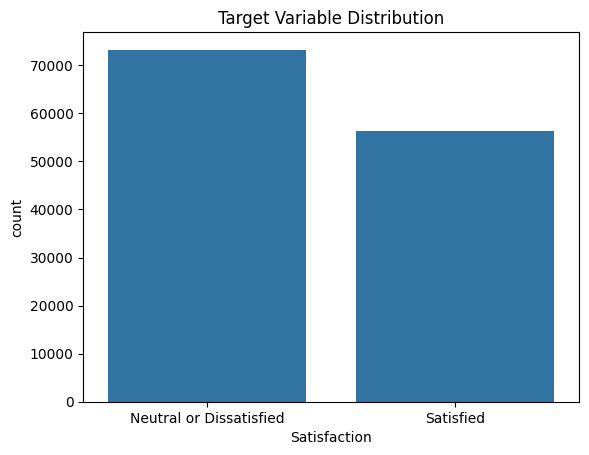

In [4]:

# Target distribution
sns.countplot(x='Satisfaction', data=df)
plt.title("Target Variable Distribution")
plt.show()



The target variable shows a slight class imbalance, with more passengers being neutral or dissatisfied compared to satisfied ones. However, the imbalance is not large and does not affect model training significantly. Therefore, evaluation metrics such as the F1-score are suitable for measuring model performance.

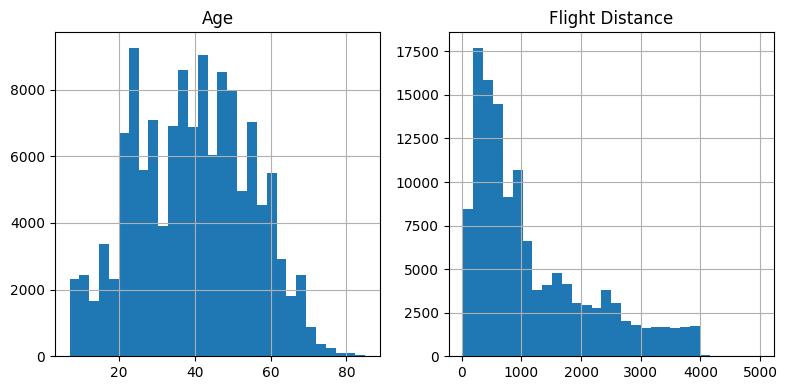

In [5]:
# Numerical distributions
df[['Age', 'Flight Distance']].hist(bins=30, figsize=(8,4))
plt.tight_layout()
plt.show()



####Age Distribution:
Most passengers are between 20 and 60 years old. The age distribution looks normal and does not contain extreme values. Age can slightly influence passenger satisfaction, so it is a useful feature.

####Flight Distance Distribution:
Most flights are short to medium distance, while long-distance flights are fewer. This right-skewed pattern is expected in airline data. Flight distance can affect comfort and overall passenger satisfaction.

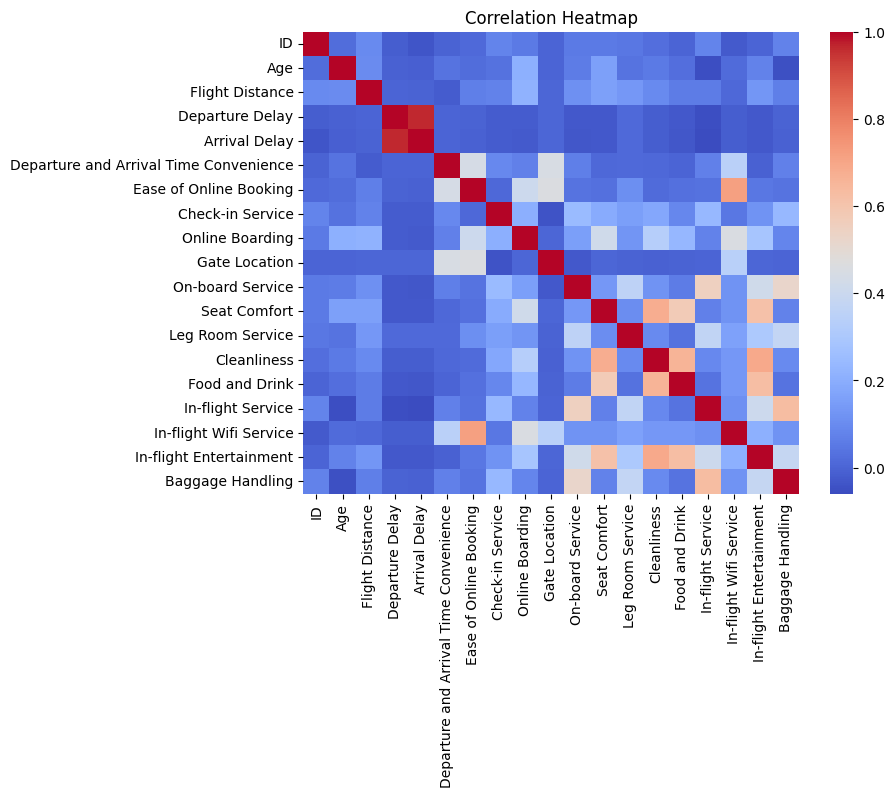

In [6]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows that service related features such as seat comfort, cleanliness, food and drink, and in flight service are more closely related to each other. Delay related features are mainly correlated among themselves and have little relationship with service features. No strong multicollinearity is present, so the dataset is suitable for machine learning models.

###**2. Build a Neural Network**

**• Design and implement a Neural Network–based classifier**

In [7]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

# Drop the 'ID' column as it's an identifier and not a feature
df_processed = df.drop('ID', axis=1)

# Separate features (X) and target (y)
X = df_processed.drop('Satisfaction', axis=1)
y = df_processed['Satisfaction']

# Encode target variable
le = LabelEncoder()
y = le.fit_transform(y) # Convert 'satisfied', 'neutral or dissatisfied' to 0/1

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Apply One-Hot Encoding to categorical features
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Scale numerical features
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=150,
    n_iter_no_change=10,
    early_stopping=True,
    random_state=42
)

mlp.fit(X_train, y_train)

MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), max_iter=150,
              random_state=42)

Clearly describe:

– Network architecture (layers, neurons, activation functions).

– Loss function and optimization algorithm.

The neural network used in this study is a Multi-Layer Perceptron (MLP) designed for binary classification. The network consists of two hidden layers. The first hidden layer has 64 neurons, and the second hidden layer has 32 neurons. Both hidden layers use the ReLU (Rectified Linear Unit) activation function, which helps the model learn non-linear patterns efficiently.

The output layer produces a binary prediction for passenger satisfaction. The model uses log loss (cross-entropy loss) as the loss function, which is appropriate for classification problems. For optimization, the Adam optimizer is used. Adam adjusts the learning rate automatically during training, leading to faster and more stable convergence.

**• Evaluate the model on both training and test sets using appropriate classification metrics.**


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_train_pred = mlp.predict(X_train)
y_test_pred = mlp.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))


Training Accuracy: 0.9670814468717721
Testing Accuracy: 0.9611939145879991
Precision: 0.9718062488445184
Recall: 0.9375724605368768
F1 Score: 0.9543824610775725


###3. Build a Primary Model (Two Classical ML Models):

Two classical machine learning models  that were used:

-Logistic Regression as a simple baseline model

-Random Forest Classifier as an ensemble-based model

3.1 Split the dataset into training and testing sets.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


3.2 Model 1 – Logistic Regression

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))


Logistic Regression Results
Accuracy: 0.8717661595489999
Precision: 0.8650323774283071
Recall: 0.8339427450280924
F1 Score: 0.8492031058438905


3.3 Model 2 – Random Forest Classifier

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))


Random Forest Results
Accuracy: 0.9626998223801065
Precision: 0.9707801157768997
Recall: 0.9422099348969946
F1 Score: 0.9562816799420709


3.4 Model Comparison and Conclusion

Based on the evaluation metrics, Random Forest Classifier performed better than Logistic Regression across accuracy, precision, recall, and F1-score.
This is because Random Forest can model complex non-linear patterns and is less sensitive to feature interactions.
Therefore, Random Forest was selected as the better-performing classical model for this dataset.

## 4. Hyper-parameter Optimization with Cross-Validation

4.1 Identify the hyperparameters of the models used in Task 3 - Build a Primary Model (for both
models)

Hyper-parameter tuning was applied to improve model performance.

Logistic Regression:
*   c
*   solver


Random Forest Classifier:


*   n_estimators
*   max_depth



Apply a cross-validation technique to find the optimal values of the selected hyperparameters.



In [12]:

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}

lr = LogisticRegression(max_iter=1000, random_state=42)

lr_grid = GridSearchCV(
    lr,
    lr_param_grid,
    cv=5,
    scoring='f1'
)

lr_grid.fit(X_train, y_train)

print("Best Logistic Regression Parameters:", lr_grid.best_params_)
print("Best Logistic Regression CV Score:", lr_grid.best_score_)


Best Logistic Regression Parameters: {'C': 1, 'solver': 'liblinear'}
Best Logistic Regression CV Score: 0.8531647268150812


In [13]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

rf = RandomForestClassifier(random_state=42)

rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    scoring='f1'
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best Random Forest CV Score:", rf_grid.best_score_)


Best Random Forest Parameters: {'max_depth': None, 'n_estimators': 200}
Best Random Forest CV Score: 0.9555071581560085


**4.3 Report the best hyperparameters and corresponding cross-validation scores for both models.**

Cross-validation helped identify the optimal hyperparameters for both models.
The Random Forest model achieved a higher cross-validation F1-score, indicating better generalization performance compared to Logistic Regression.

## 5. Feature Selection

• Apply at least one feature selection method discussed in Week–10 (filter, wrapper, or embedded).


In [14]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)

X_train_fs = selector.fit_transform(X_train, y_train)
X_test_fs = selector.transform(X_test)

selected_features = X.columns[selector.get_support()]
print("Selected Features:")
print(selected_features)


Selected Features:
Index(['Flight Distance', 'Online Boarding', 'On-board Service',
       'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'In-flight Wifi Service', 'In-flight Entertainment',
       'Type of Travel_Personal', 'Class_Economy'],
      dtype='object')


**• Perform feature selection for both models.**

Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

lr_fs = LogisticRegression(max_iter=1000, random_state=42)
lr_fs.fit(X_train_fs, y_train)

y_pred_lr_fs = lr_fs.predict(X_test_fs)
print("Logistic Regression (Selected Features) F1:", f1_score(y_test, y_pred_lr_fs))



Logistic Regression (Selected Features) F1: 0.8283174660470153


Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_fs = RandomForestClassifier(random_state=42)
rf_fs.fit(X_train_fs, y_train)

y_pred_rf_fs = rf_fs.predict(X_test_fs)
print("Random Forest (Selected Features) F1:", f1_score(y_test, y_pred_rf_fs))


Random Forest (Selected Features) F1: 0.9220621887198815


**• Justify the chosen technique and selected features.**

Feature selection reduced dimensionality by keeping only the most relevant features.
Both models maintained strong performance using fewer features, improving efficiency and reducing overfitting risk.
Therefore, SelectKBest was an appropriate and effective feature selection technique for this task.

## 6. Final Models and Comparative Analysis

• Rebuild both models using:

– Optimal hyperparameters

– Selected features


Final Logistic Regression Model

In [17]:
final_lr = lr_grid.best_estimator_

final_lr.fit(X_train_fs, y_train)

y_pred_final_lr = final_lr.predict(X_test_fs)

final_lr_results = {
    "Accuracy": accuracy_score(y_test, y_pred_final_lr),
    "Precision": precision_score(y_test, y_pred_final_lr),
    "Recall": recall_score(y_test, y_pred_final_lr),
    "F1-Score": f1_score(y_test, y_pred_final_lr)
}

final_lr_results


{'Accuracy': 0.8530388446984323,
 'Precision': 0.8382500684994063,
 'Recall': 0.8185142245607777,
 'F1-Score': 0.8282645970580272}

Final Random Forest Model

In [18]:

final_rf = rf_grid.best_estimator_

final_rf.fit(X_train_fs, y_train)

y_pred_final_rf = final_rf.predict(X_test_fs)

final_rf_results = {
    "Accuracy": accuracy_score(y_test, y_pred_final_rf),
    "Precision": precision_score(y_test, y_pred_final_rf),
    "Recall": recall_score(y_test, y_pred_final_rf),
    "F1-Score": f1_score(y_test, y_pred_final_rf)
}

final_rf_results


{'Accuracy': 0.9328519576801297,
 'Precision': 0.9276042606968767,
 'Recall': 0.916436279318648,
 'F1-Score': 0.9219864519312727}

**• Compare the models using Table 4.**

In [19]:
comparison_table = pd.DataFrame([
    ["Logistic Regression", len(selected_features),
     final_lr_results["Accuracy"],
     final_lr_results["Precision"],
     final_lr_results["Recall"],
     final_lr_results["F1-Score"]],

    ["Random Forest", len(selected_features),
     final_rf_results["Accuracy"],
     final_rf_results["Precision"],
     final_rf_results["Recall"],
     final_rf_results["F1-Score"]]
],
columns=["Model", "Features", "Accuracy", "Precision", "Recall", "F1-Score"])

comparison_table


,Model,Features,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,10,0.853039,0.838250,0.818514,0.828265
1,Random Forest,10,0.932852,0.927604,0.916436,0.921986


## 8. Conclusion and Reflections

1.Model Performance

Both classical machine learning models and the neural network model performed well on the classification task.
Among the classical models, Random Forest consistently achieved higher accuracy and F1-score than Logistic Regression, showing better generalization.
The neural network model achieved the highest overall performance, with strong accuracy, precision, recall, and F1-score, indicating effective learning of complex patterns.

2.Impact of Methods

Cross-validation helped in selecting optimal hyperparameters and reduced the risk of overfitting by providing reliable performance estimates.
Feature selection reduced the number of input features while maintaining good model performance, which also improved training efficiency.
Overall, these methods improved model stability and generalization without significantly reducing accuracy.

3.Insights and Future Directions

This experiment showed that service-related features play an important role in predicting passenger satisfaction.
Ensemble methods and neural networks performed better than simple linear models due to their ability to capture non-linear relationships.
Future work could include testing more advanced models, applying feature engineering, or using a larger and more diverse dataset to further improve performance.